In [1]:
import numpy as np
import matplotlib.pyplot as plt

from muutils.dbg import dbg_tensor

from attention_motifs.util import plot_figs, load_activations, get_single_attn_pattern
from attention_motifs.transition_tensor import transition_tensor, tt_fig

/home/miv/projects/attn/attention-motifs/attention_motifs/transition_tensor.py:15: SyntaxWarning: invalid escape sequence '\s'
  "$H(p,q)=-\sum _{x\in {\mathcal {X}}}p(x)\,\log q(x)$"


In [2]:
MODEL_NAME: str = "pythia-14m"
MODEL_CFG: dict
PROMPTS: list[dict]
ACTIVATIONS: list[np.lib.npyio.NpzFile]
MODEL_CFG, PROMPTS, ACTIVATIONS = load_activations(MODEL_NAME)

In [3]:
_idxs, _tt, _res = transition_tensor(
	get_single_attn_pattern(0, 0, 0, activations=ACTIVATIONS),
	exact=20,
	approx_l10=3.0,
	approx_pts=20,
)
dbg_tensor(_idxs)
dbg_tensor(_tt)
dbg_tensor(_res)

print()

[ tmp/ipykernel_85219/3293997746.py:7 ] _idxs = shape=(40,), dtype=dtype('int64')
[ tmp/ipykernel_85219/3293997746.py:8 ] _tt = shape=(40, 82, 82), dtype=dtype('float32')
[ tmp/ipykernel_85219/3293997746.py:9 ] _res = shape=(40, 82), sum=nan, dtype=dtype('float32')


[ attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 0, 0)
/tmp/ipykernel_85219/209441930.py:17: RuntimeWarning: invalid value encountered in log10
  axs[1].matshow(np.log10(1 - tt[:, :, 0].T + 1e-8), aspect=tt.shape[0] / tt.shape[1])


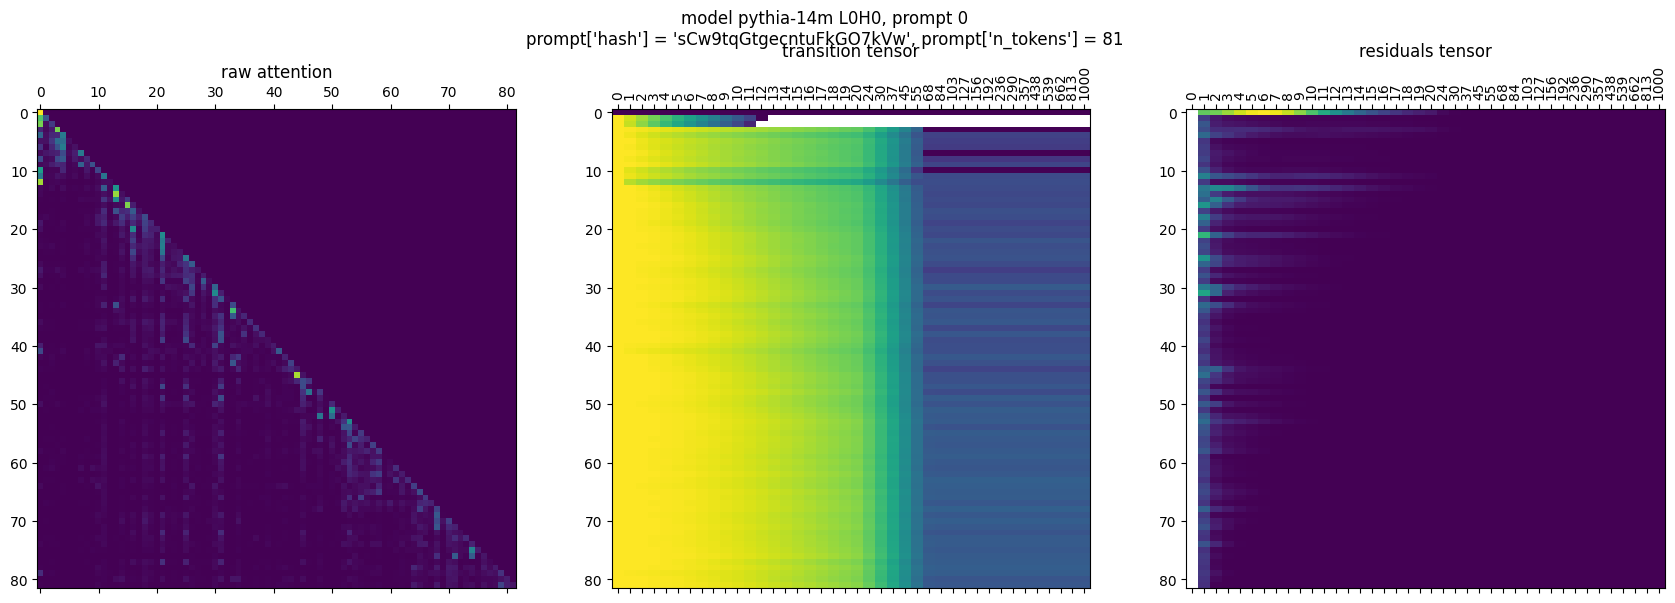

[ attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 1, 0)


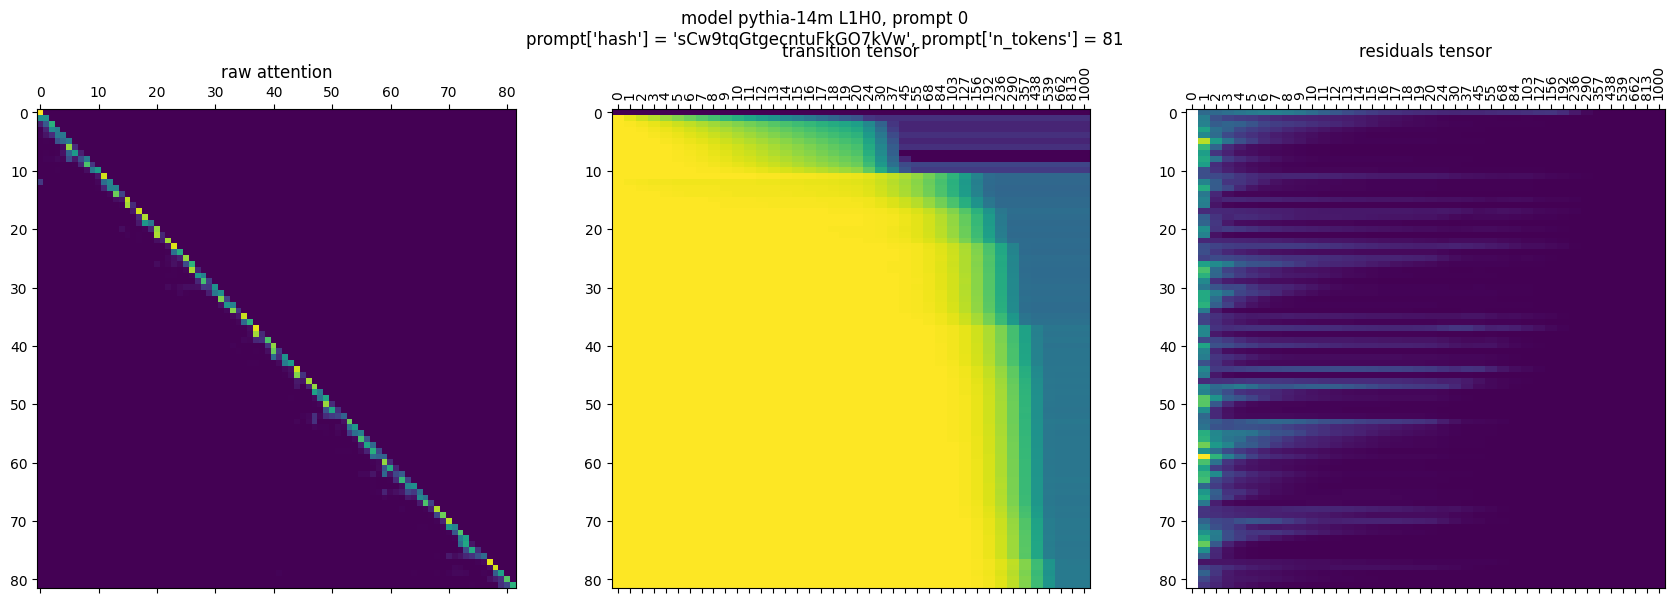

[ attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 2, 0)
/tmp/ipykernel_85219/209441930.py:17: RuntimeWarning: invalid value encountered in log10
  axs[1].matshow(np.log10(1 - tt[:, :, 0].T + 1e-8), aspect=tt.shape[0] / tt.shape[1])


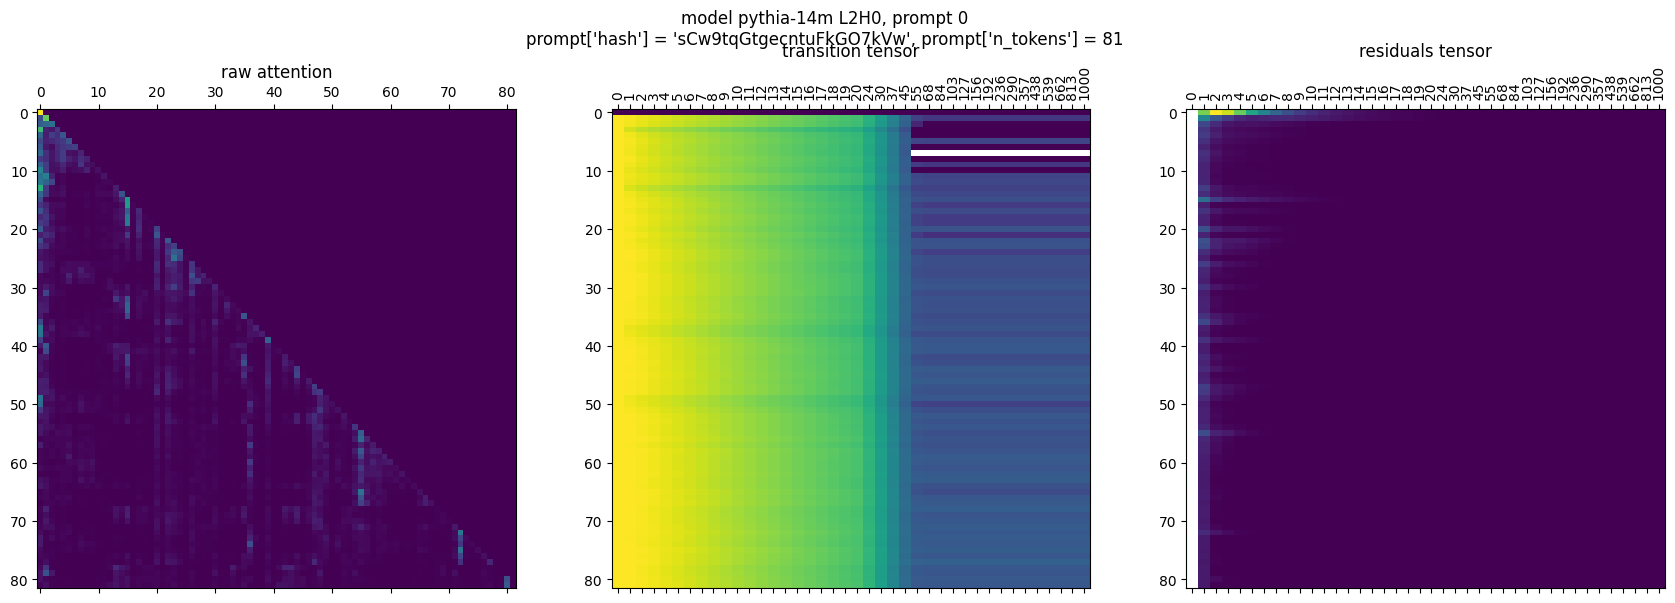

[ attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 3, 0)
/tmp/ipykernel_85219/209441930.py:17: RuntimeWarning: invalid value encountered in log10
  axs[1].matshow(np.log10(1 - tt[:, :, 0].T + 1e-8), aspect=tt.shape[0] / tt.shape[1])


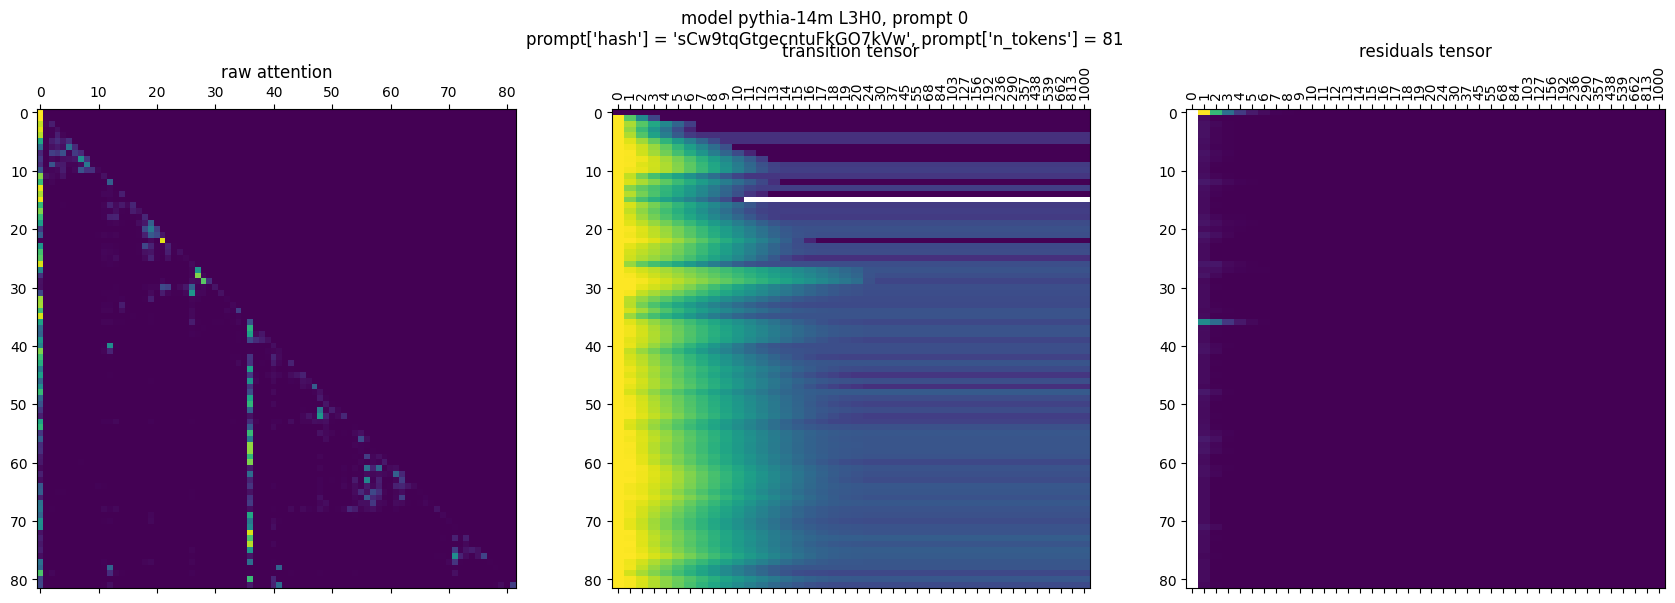

[ attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 4, 0)


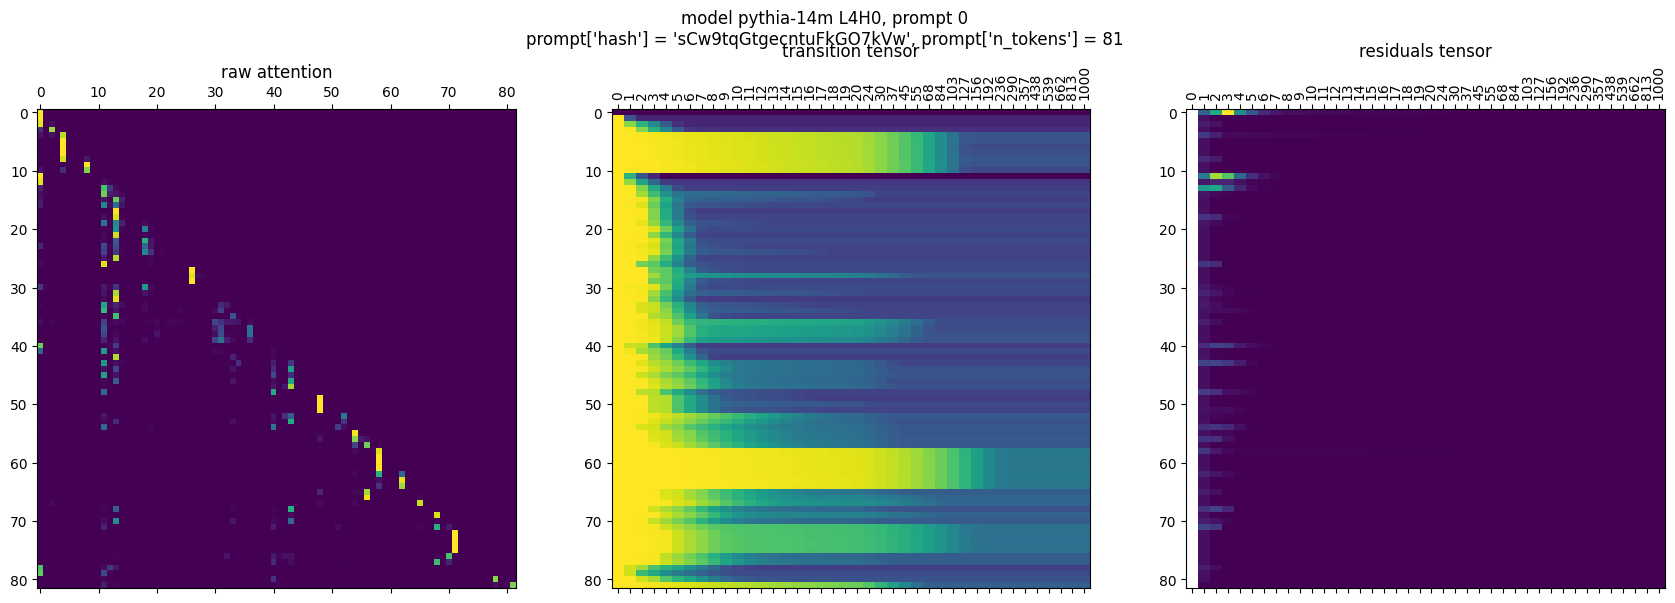

[ attention_motifs/util.py:72 ] (p_idx, lyr, head) = (0, 5, 0)
/tmp/ipykernel_85219/209441930.py:17: RuntimeWarning: invalid value encountered in log10
  axs[1].matshow(np.log10(1 - tt[:, :, 0].T + 1e-8), aspect=tt.shape[0] / tt.shape[1])


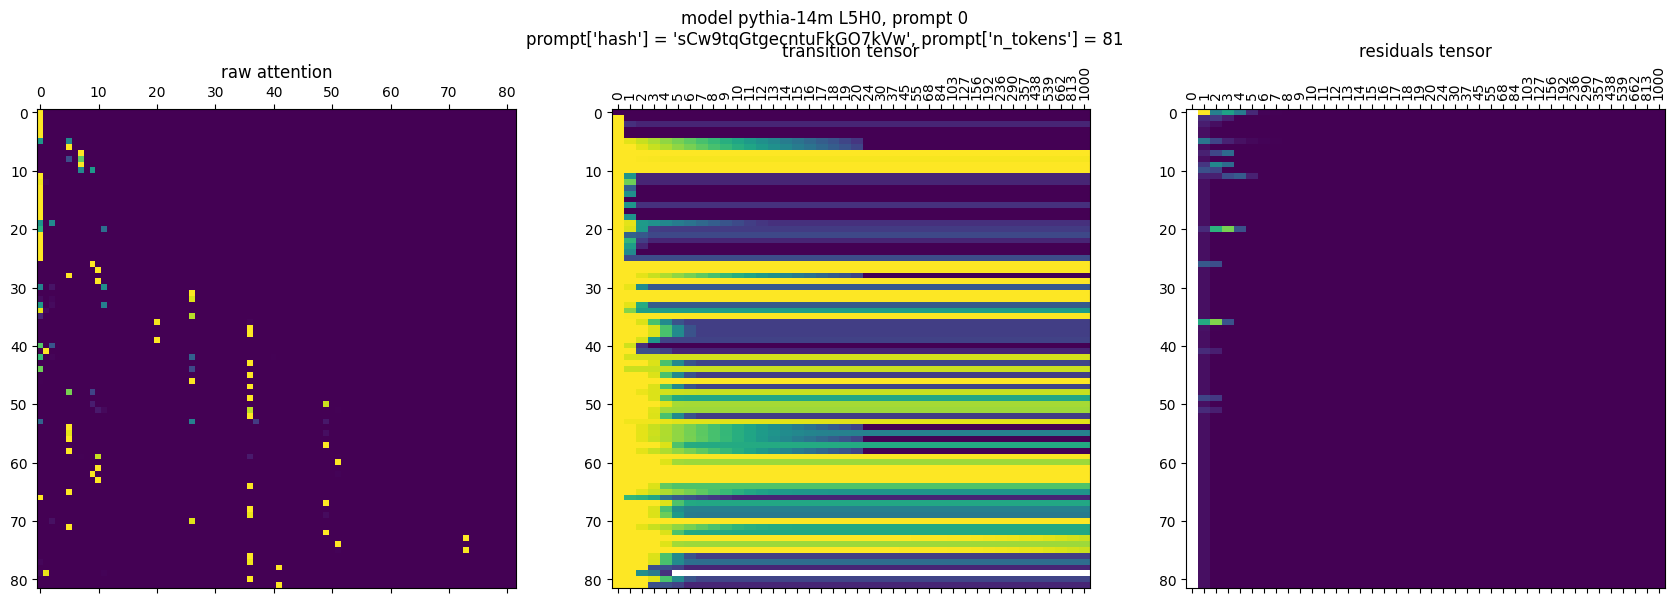

[ attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 0, 0)


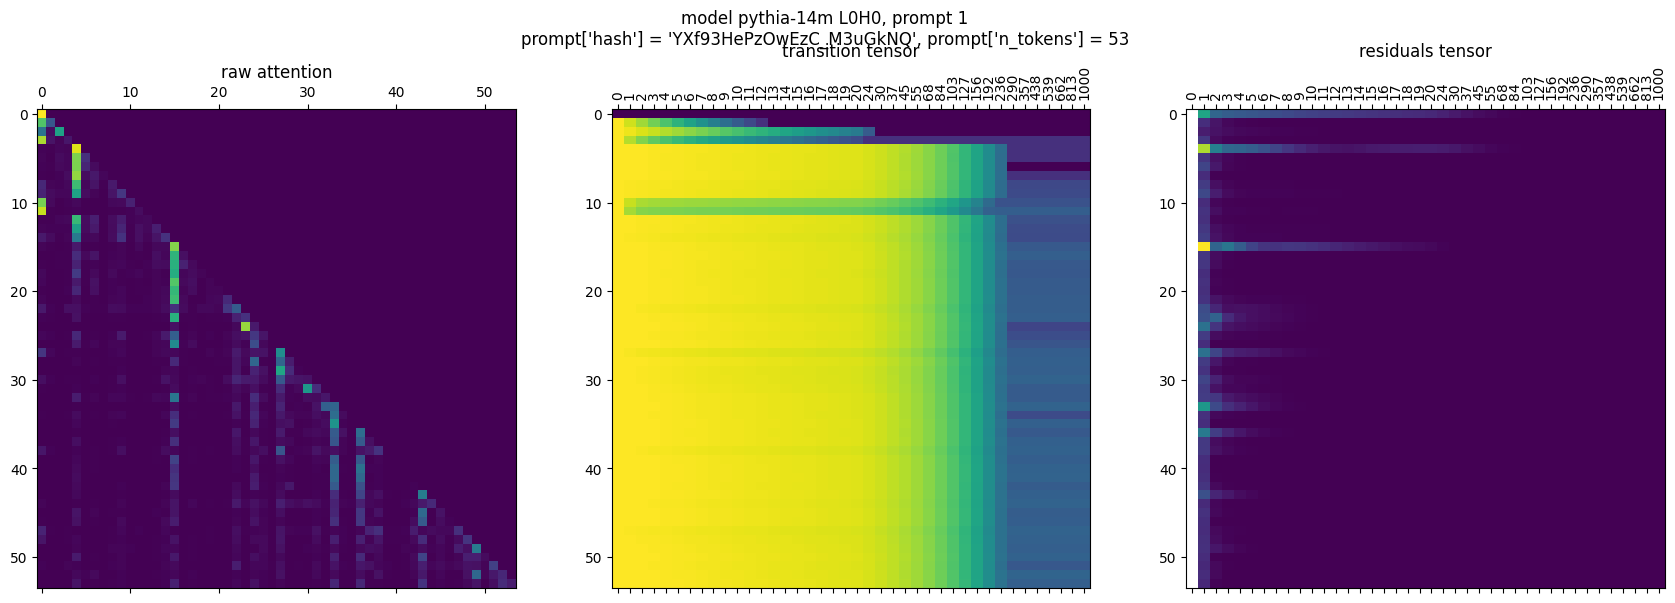

[ attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 1, 0)
/tmp/ipykernel_85219/209441930.py:17: RuntimeWarning: invalid value encountered in log10
  axs[1].matshow(np.log10(1 - tt[:, :, 0].T + 1e-8), aspect=tt.shape[0] / tt.shape[1])


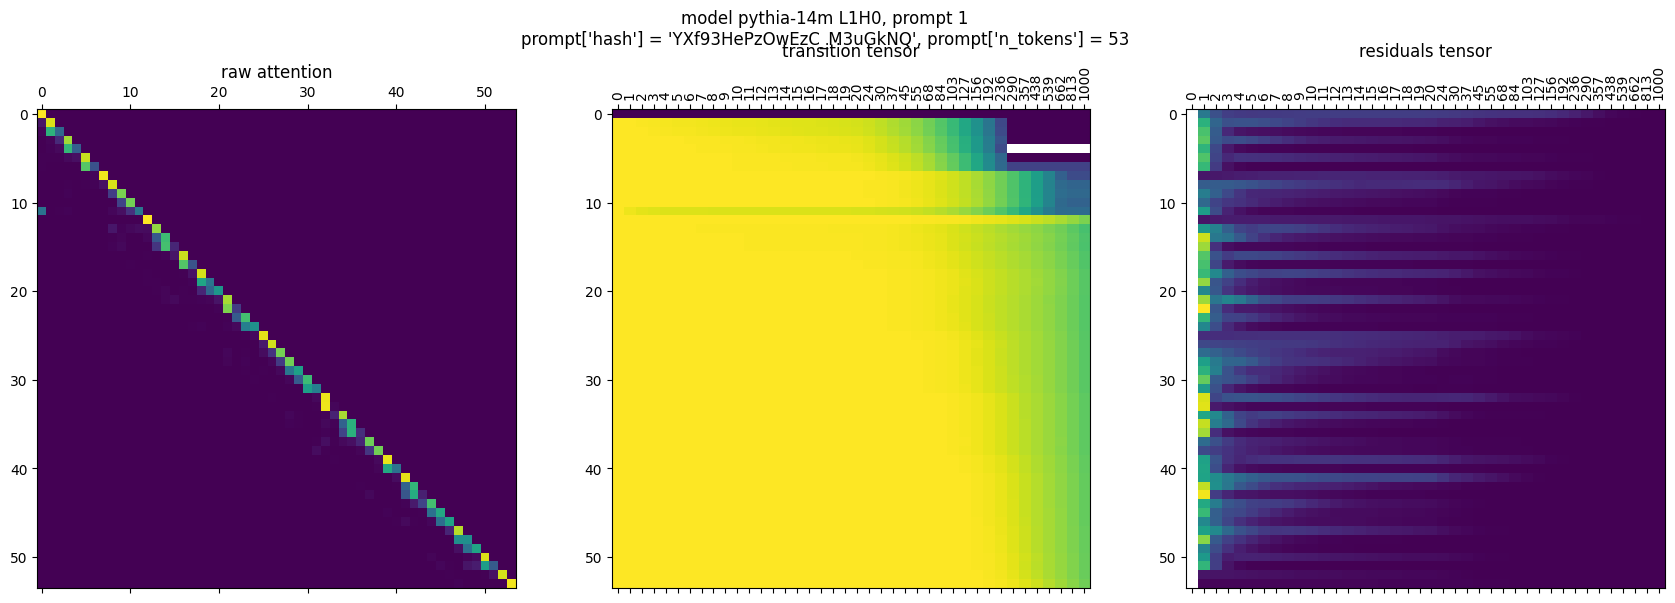

[ attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 2, 0)
/tmp/ipykernel_85219/209441930.py:17: RuntimeWarning: invalid value encountered in log10
  axs[1].matshow(np.log10(1 - tt[:, :, 0].T + 1e-8), aspect=tt.shape[0] / tt.shape[1])


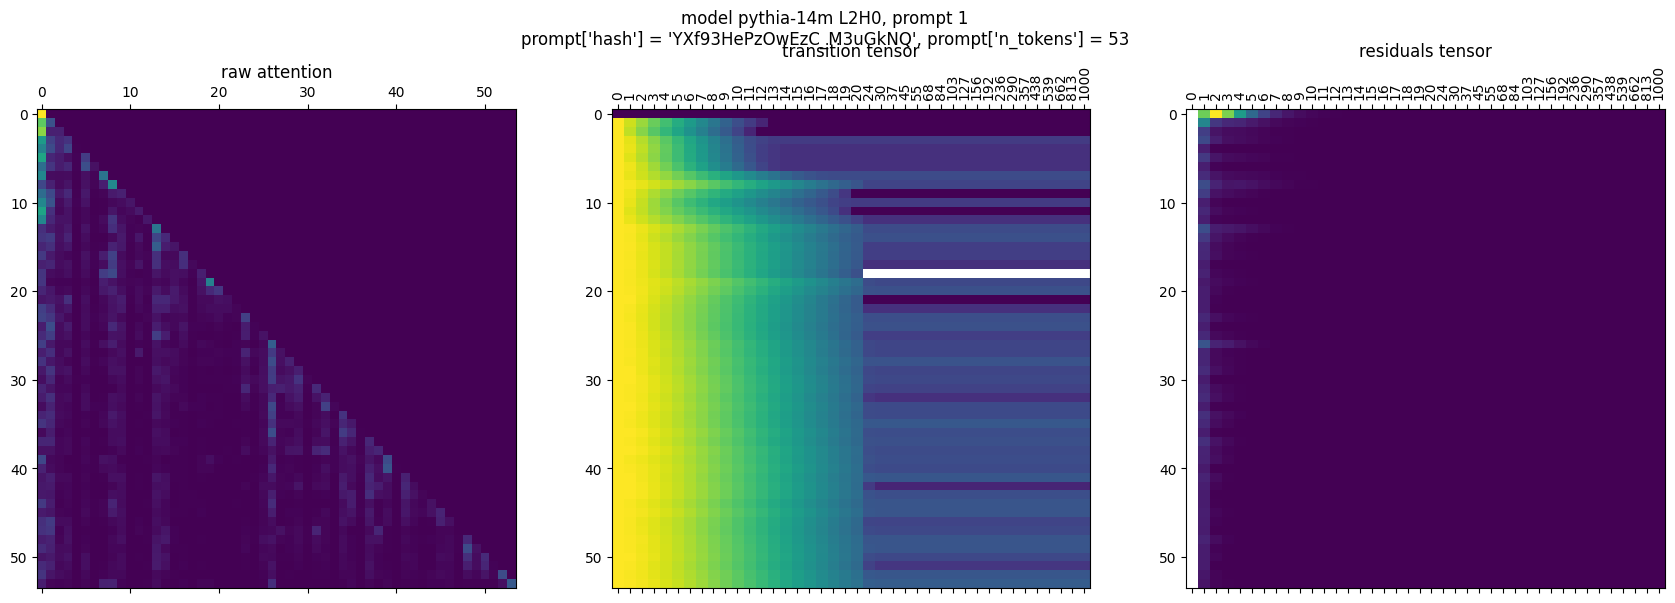

[ attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 3, 0)
/tmp/ipykernel_85219/209441930.py:17: RuntimeWarning: invalid value encountered in log10
  axs[1].matshow(np.log10(1 - tt[:, :, 0].T + 1e-8), aspect=tt.shape[0] / tt.shape[1])


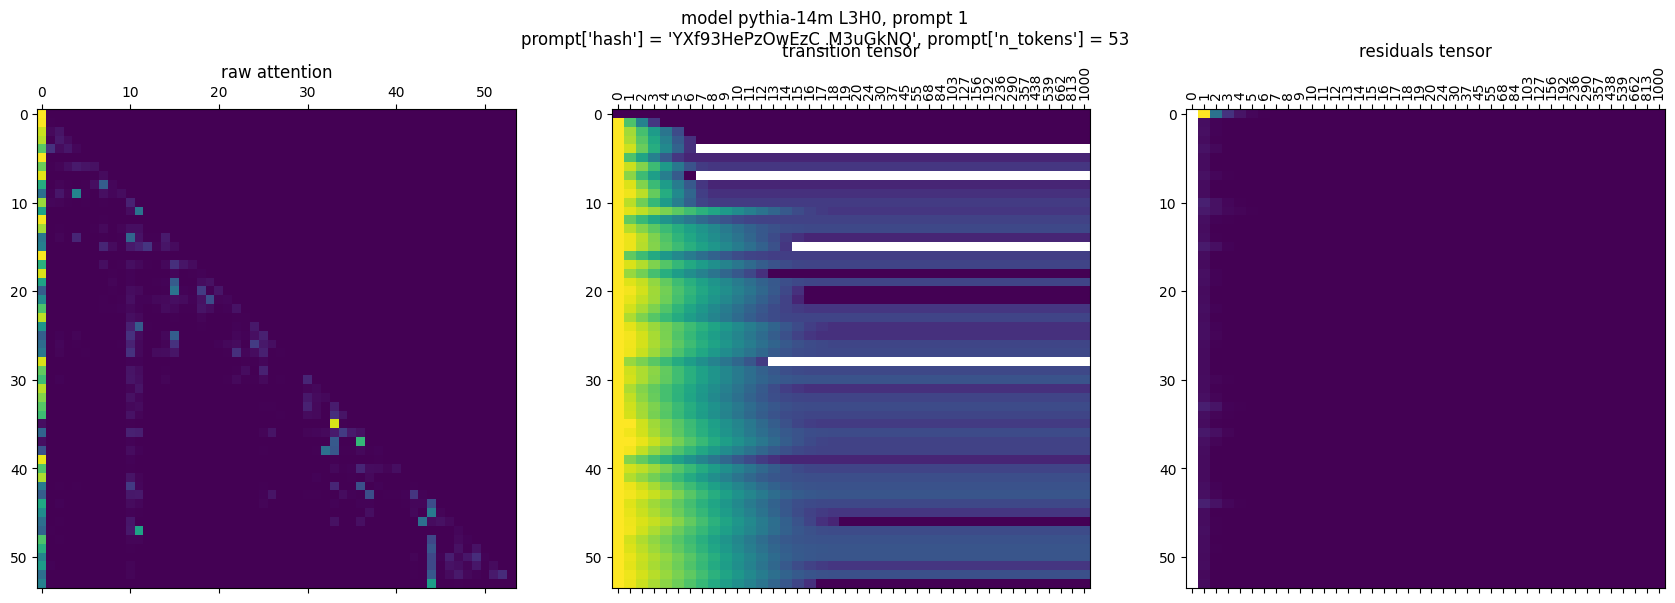

[ attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 4, 0)
/tmp/ipykernel_85219/209441930.py:17: RuntimeWarning: invalid value encountered in log10
  axs[1].matshow(np.log10(1 - tt[:, :, 0].T + 1e-8), aspect=tt.shape[0] / tt.shape[1])


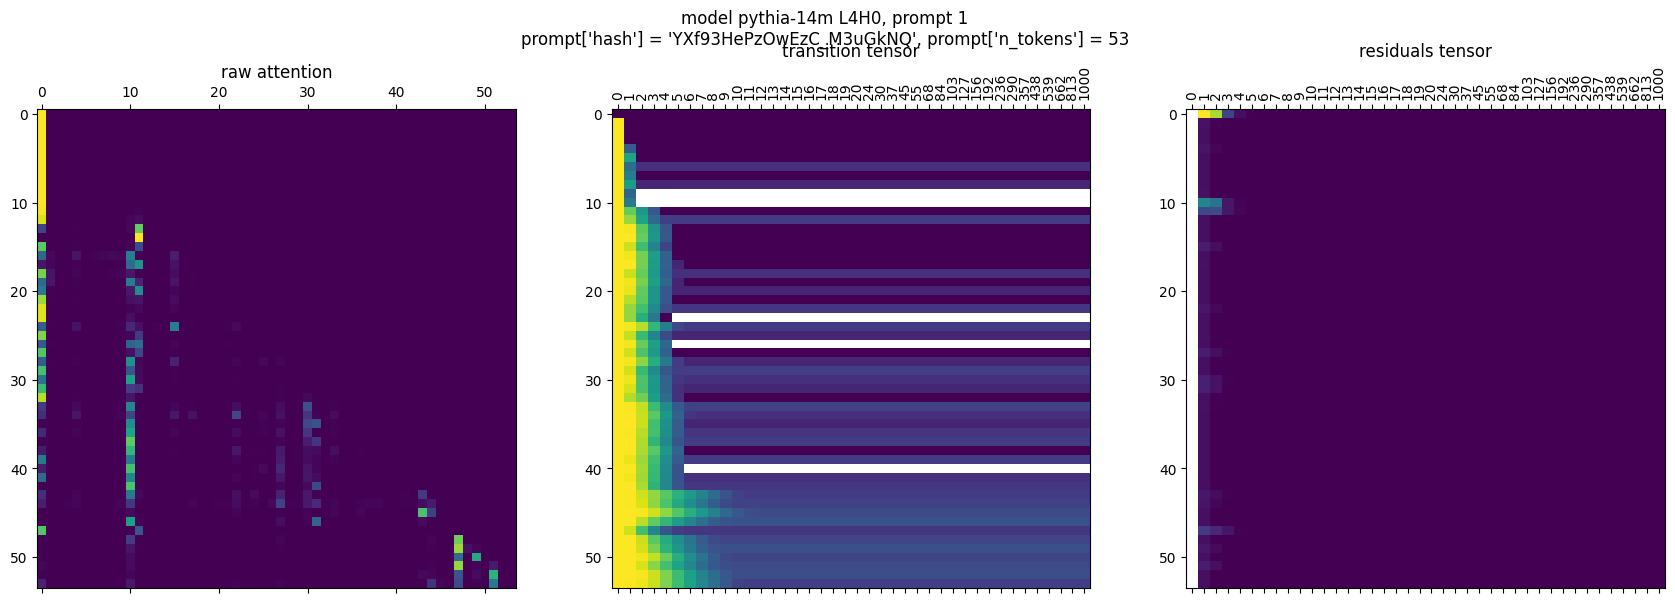

[ attention_motifs/util.py:72 ] (p_idx, lyr, head) = (1, 5, 0)
/tmp/ipykernel_85219/209441930.py:17: RuntimeWarning: invalid value encountered in log10
  axs[1].matshow(np.log10(1 - tt[:, :, 0].T + 1e-8), aspect=tt.shape[0] / tt.shape[1])


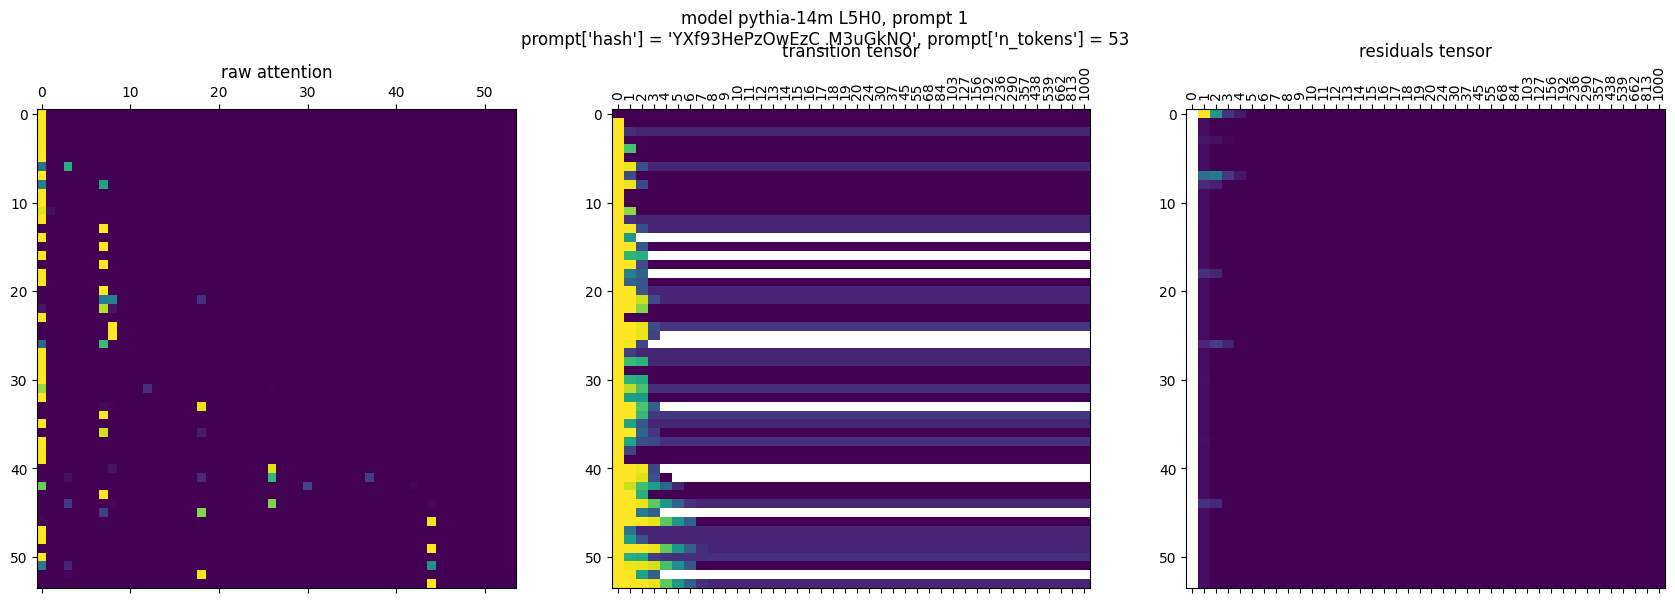

In [4]:
def fig(
	A: np.ndarray,
	axs: list[plt.Axes],
	p_idx: int,
	lyr: int,
	head: int,
):
	#
	axs[0].set_title("raw attention")
	axs[0].matshow(A)

	# compute transition_tensor
	idxs, tt, res = transition_tensor(A, exact=20, approx_l10=3.0,			 approx_pts=20)

	#
	axs[1].set_title("transition tensor")
	axs[1].matshow(np.log10(1 - tt[:, :, 0].T + 1e-8), aspect=tt.shape[0] / tt.shape[1])
	axs[1].set_xticks(range(len(idxs)))
	axs[1].set_xticklabels(idxs)
	axs[1].tick_params(axis="x", rotation=90)

	#
	axs[2].set_title("residuals tensor")
	# aspect shoudl be such that the image is square, although the matrix is not
	axs[2].matshow(res.T, aspect=(res.shape[0] / res.shape[1]))
	axs[2].set_xticks(range(len(idxs)))
	axs[2].set_xticklabels(idxs)
	axs[2].tick_params(axis="x", rotation=90)

plot_figs(
	n_figures=3,
	model_cfg=MODEL_CFG,
	prompt_dicts=PROMPTS,
	activations=ACTIVATIONS,
	figure_func=fig,
	prompts=[0, 1],
	layers=None,
	heads=[0],
)

plt.show()

In [50]:
import torch
from transformer_lens import HookedTransformer, HookedTransformerConfig

model_trained = HookedTransformer.from_pretrained("gpt2-small")
model_cfg = model_trained.cfg

# randomize the weights of model
model = HookedTransformer(HookedTransformerConfig.from_dict(model_cfg.to_dict()))

state_dict = model.state_dict()

for k, tensor in state_dict.items():
	if tensor.isnan().any():
		# set the tensor to random gaussian
		print(f"replacing {k} with random tensor")
		state_dict[k] = torch.randn_like(tensor)

model.load_state_dict(state_dict)

for k, tensor in model.state_dict().items():
	if tensor.isnan().any():
		# set the tensor to random gaussian
		print(f"{k} still has nans")



logits, cache = model.run_with_cache("tial idea was to create something where humanity tried to evolve to a next level but had some kind of foe trying to stop them from doing so. I kind of had this image of human souls fly")

Loaded pretrained model gpt2-small into HookedTransformer
replacing blocks.0.mlp.W_out with random tensor
replacing blocks.1.mlp.W_in with random tensor
replacing blocks.4.mlp.W_in with random tensor
replacing blocks.5.mlp.W_out with random tensor
replacing blocks.7.mlp.W_out with random tensor
replacing blocks.8.mlp.W_in with random tensor
replacing blocks.10.mlp.W_out with random tensor


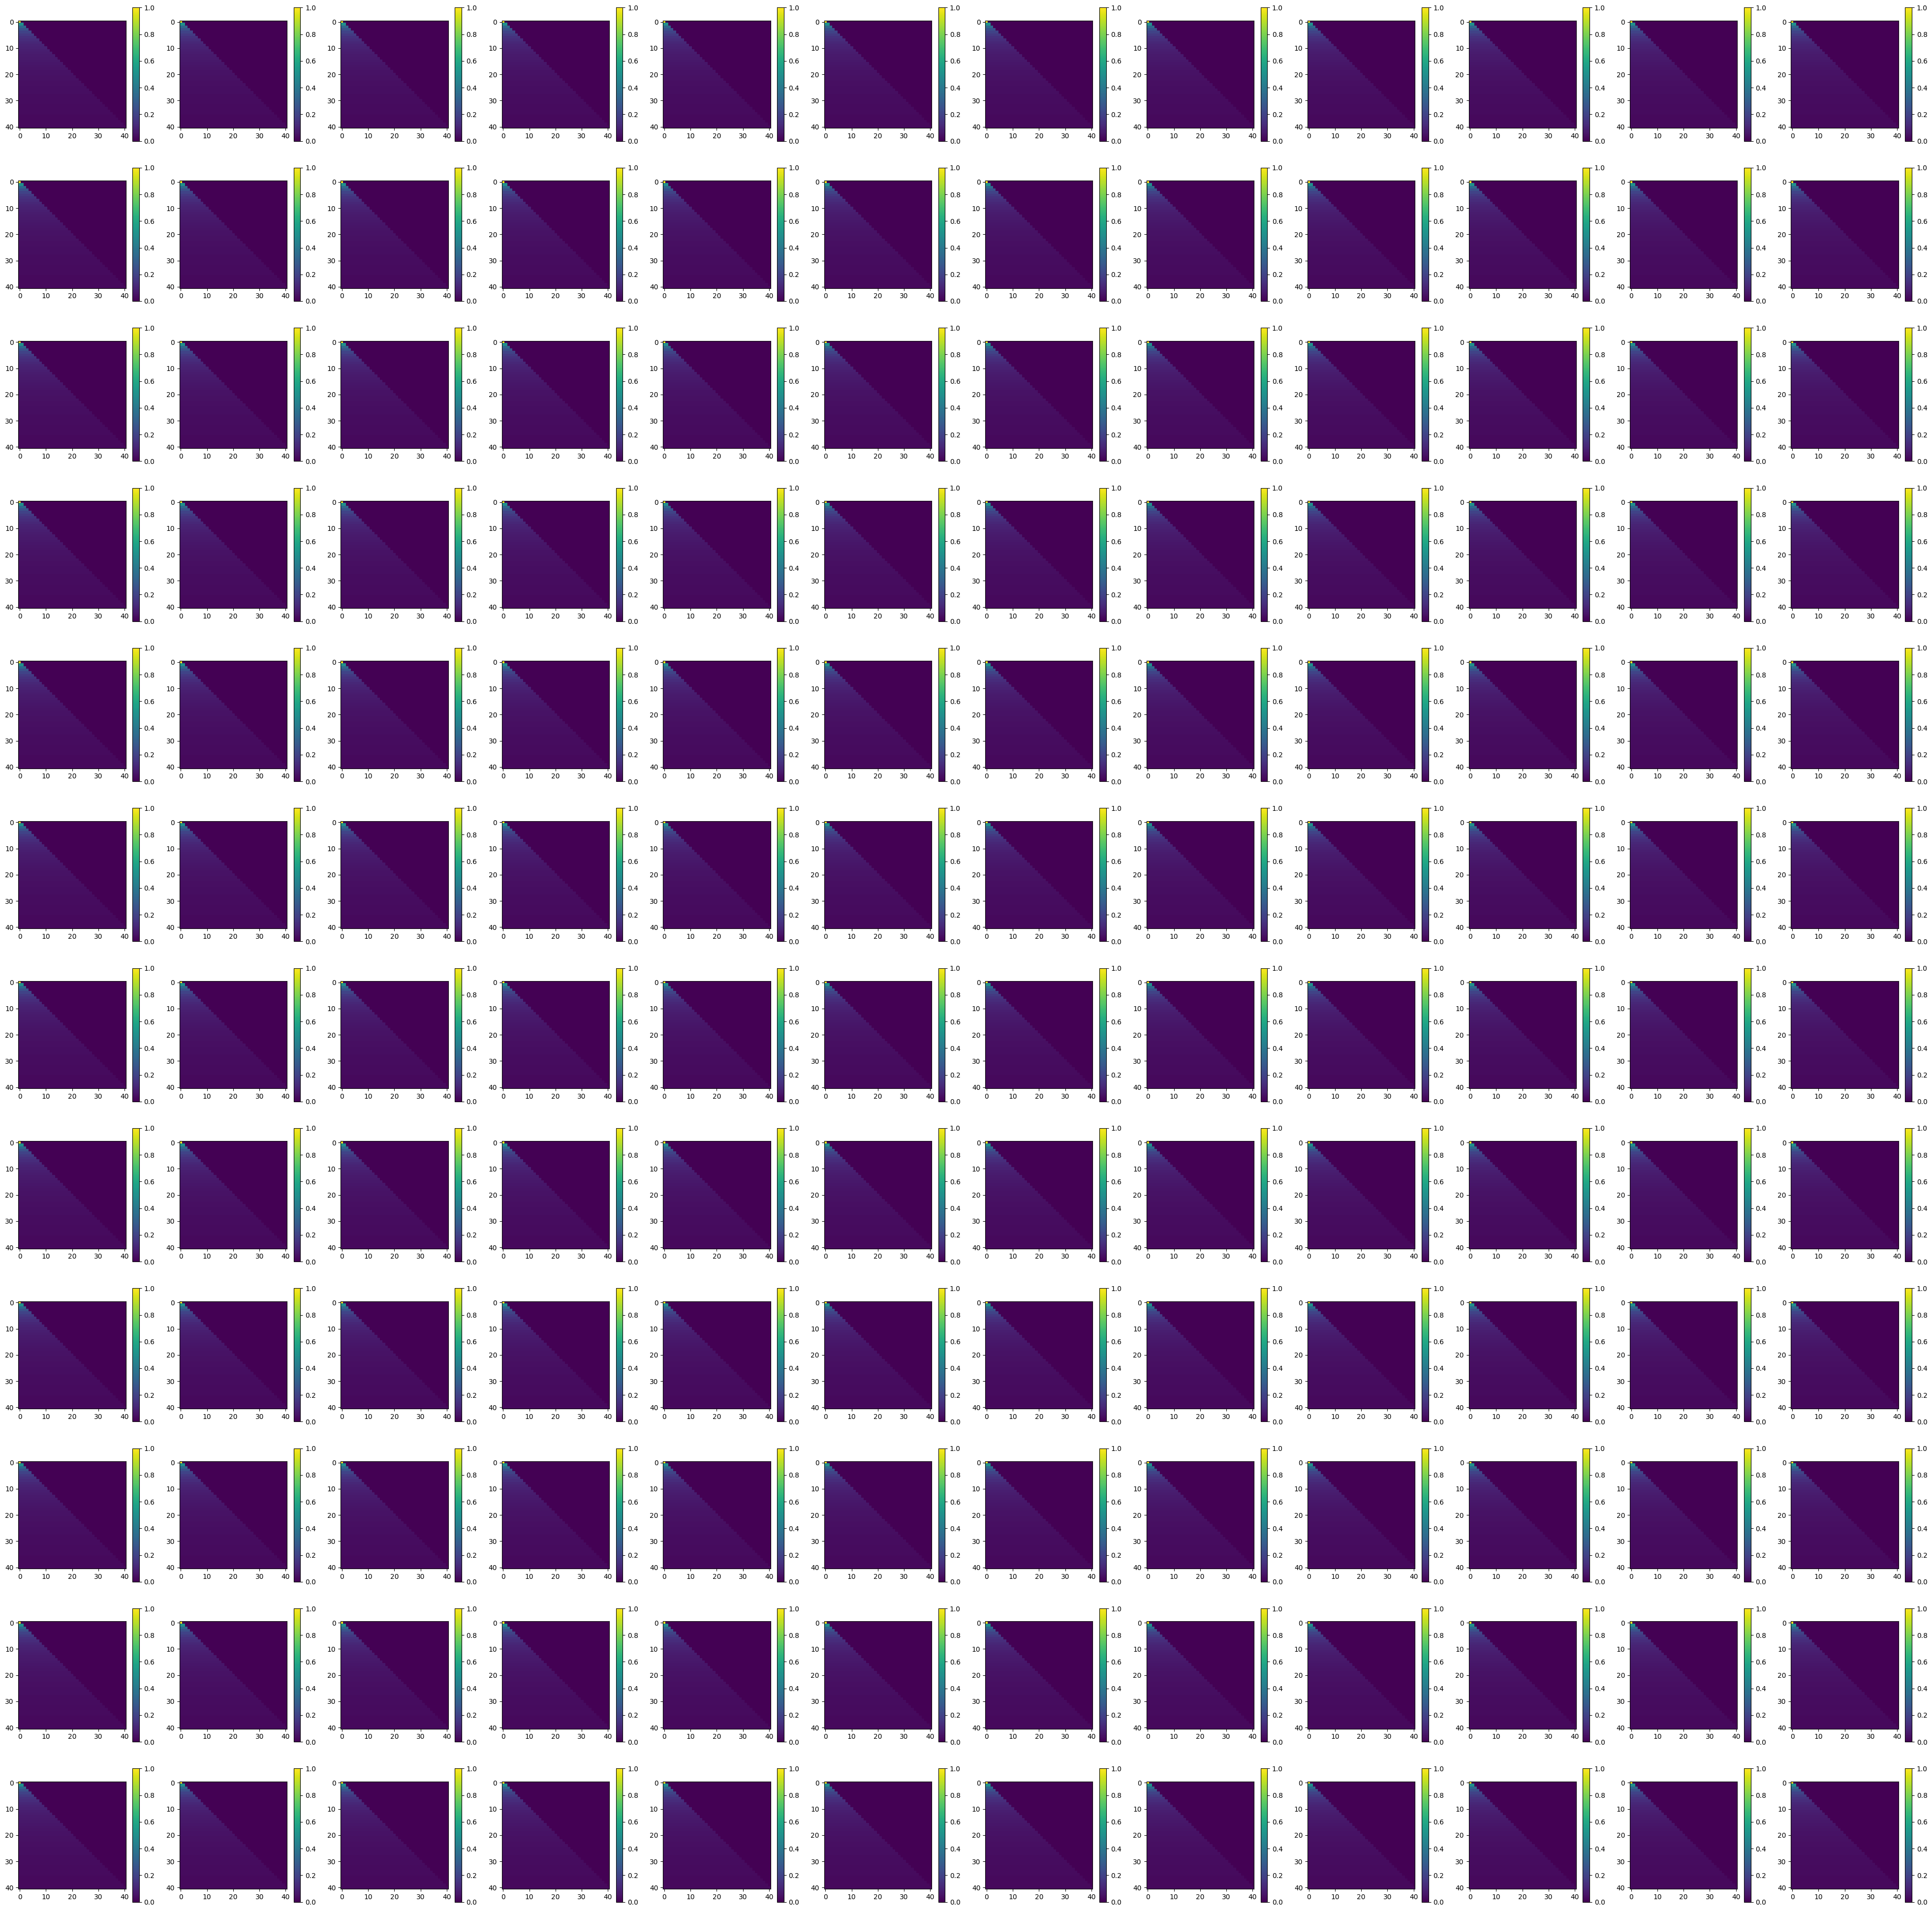

In [53]:
fig, ax = plt.subplots(ncols=model_cfg.n_heads, nrows=model_cfg.n_layers, figsize=(50, 50))

for layer in range(model_cfg.n_layers):
	for head in range(model_cfg.n_heads):
		# ax[layer, head].matshow(cache[f"blocks.{layer}.attn.hook_attn_scores"][0, head].cpu().numpy())
		# with colorbar
		im = ax[layer, head].imshow(cache[f"blocks.{layer}.attn.hook_pattern"][0, head].cpu().numpy())
		fig.colorbar(im, ax=ax[layer, head])